In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="XXXXXXXX")
project = rf.workspace("XXXXX").project("defect-segmentation-with-u-net")
version = project.version(1)
dataset = version.download("coco-segmentation")

print(dataset.location)


loading Roboflow workspace...
loading Roboflow project...
d:\Amr\Portfolio\All time project\ready to publish\CV\Project 6\Defect-segmentation-with-u-net-1


In [ ]:
import json
import numpy as np
import cv2
import os
from pycocotools.coco import COCO

# Directly use path download
coco_json_path = os.path.join(dataset.location, "train", "_annotations.coco.json")
images_dir = os.path.join(dataset.location, "train")
output_mask_dir = os.path.join(dataset.location, "masks")

os.makedirs(output_mask_dir, exist_ok=True)

# Converting COCO annotations to binary masks
coco = COCO(coco_json_path)  

for img_id in coco.imgs:
    img_info = coco.imgs[img_id]
    filename = img_info["file_name"]
    height, width = img_info["height"], img_info["width"]

    mask = np.zeros((height, width), dtype=np.uint8)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        m = coco.annToMask(ann)  
        mask[m == 1] = 255       

    cv2.imwrite(os.path.join(output_mask_dir, filename), mask)

print("finish and save to:", output_mask_dir)


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
finish and save to: d:\Amr\Portfolio\All time project\ready to publish\CV\Project 6\Defect-segmentation-with-u-net-1\masks


In [3]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

VALID_EXT = (".jpg", ".jpeg", ".png")

class DefectDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        # Just take picture that have pair
        self.filenames = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith(VALID_EXT)
            and os.path.exists(os.path.join(mask_dir, f))
        ])

        self.img_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])
        self.mask_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]

        img_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.img_transform(image)
        mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()  

        return image, mask


full_dataset = DefectDataset(
    image_dir=os.path.join(dataset.location, "train"),
    mask_dir=os.path.join(dataset.location, "masks"),
    img_size=256
)

# Train/val split (80/20) 
torch.manual_seed(42)
n_val = max(1, int(0.2 * len(full_dataset)))
n_train = len(full_dataset) - n_val
train_dataset, val_dataset = random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")


Train: 29 | Val: 7


In [4]:
import torch
import torch.nn as nn

def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, in_c=3, out_c=1):
        super().__init__()
        # Encoder
        self.enc1 = conv_block(in_c, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = conv_block(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        # Output layer -> 1 channel LOGITS (defect vs background)
        self.out = nn.Conv2d(64, out_c, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)  


In [5]:
import torch.nn.functional as F

def dice_loss_from_logits(logits, target, smooth=1.0):
    pred = torch.sigmoid(logits).view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice


def make_combined_loss(pos_weight):
    bce_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def combined_loss(logits, target):
        bce = bce_fn(logits, target)
        dice = dice_loss_from_logits(logits, target)
        return bce + dice

    return combined_loss


def estimate_pos_weight(loader, device):
    """Ratio background/defect pixel from data training for pos_weight BCE."""
    total_pos, total_pixels = 0.0, 0.0
    for _, masks in loader:
        total_pos += masks.sum().item()
        total_pixels += masks.numel()
    total_neg = total_pixels - total_pos
    ratio = total_neg / max(total_pos, 1.0) 
    return torch.tensor([ratio], device=device)


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

pos_weight = estimate_pos_weight(train_loader, device)
criterion = make_combined_loss(pos_weight)

best_val_loss = float("inf")
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, masks)
            val_loss += loss.item() * images.size(0)
    val_loss /= max(len(val_dataset), 1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "unet_defect_best.pth")

print("Training finished bessst model saved as unet_defect_best.pth")
print("Best val loss:", best_val_loss)


Device: cuda
Epoch 1/50 | Train Loss: 2.1017 | Val Loss: 2.2066
Epoch 2/50 | Train Loss: 1.7394 | Val Loss: 2.1965
Epoch 3/50 | Train Loss: 1.6791 | Val Loss: 2.1877
Epoch 4/50 | Train Loss: 1.6166 | Val Loss: 2.1840
Epoch 5/50 | Train Loss: 1.5583 | Val Loss: 2.1817
Epoch 6/50 | Train Loss: 1.5113 | Val Loss: 2.1715
Epoch 7/50 | Train Loss: 1.4772 | Val Loss: 2.1577
Epoch 8/50 | Train Loss: 1.4503 | Val Loss: 2.0303
Epoch 9/50 | Train Loss: 1.4232 | Val Loss: 1.9742
Epoch 10/50 | Train Loss: 1.4052 | Val Loss: 1.7056
Epoch 11/50 | Train Loss: 1.3874 | Val Loss: 1.7940
Epoch 12/50 | Train Loss: 1.3711 | Val Loss: 1.5947
Epoch 13/50 | Train Loss: 1.3593 | Val Loss: 1.4164
Epoch 14/50 | Train Loss: 1.3488 | Val Loss: 1.3926
Epoch 15/50 | Train Loss: 1.3419 | Val Loss: 1.3749
Epoch 16/50 | Train Loss: 1.3321 | Val Loss: 1.3409
Epoch 17/50 | Train Loss: 1.3269 | Val Loss: 1.3231
Epoch 18/50 | Train Loss: 1.3209 | Val Loss: 1.3172
Epoch 19/50 | Train Loss: 1.3169 | Val Loss: 1.3156
Epoch 20

Pred prob -> min: 0.1660, max: 1.0000, mean: 0.2180
Dice score: 0.7083 | IoU: 0.5484


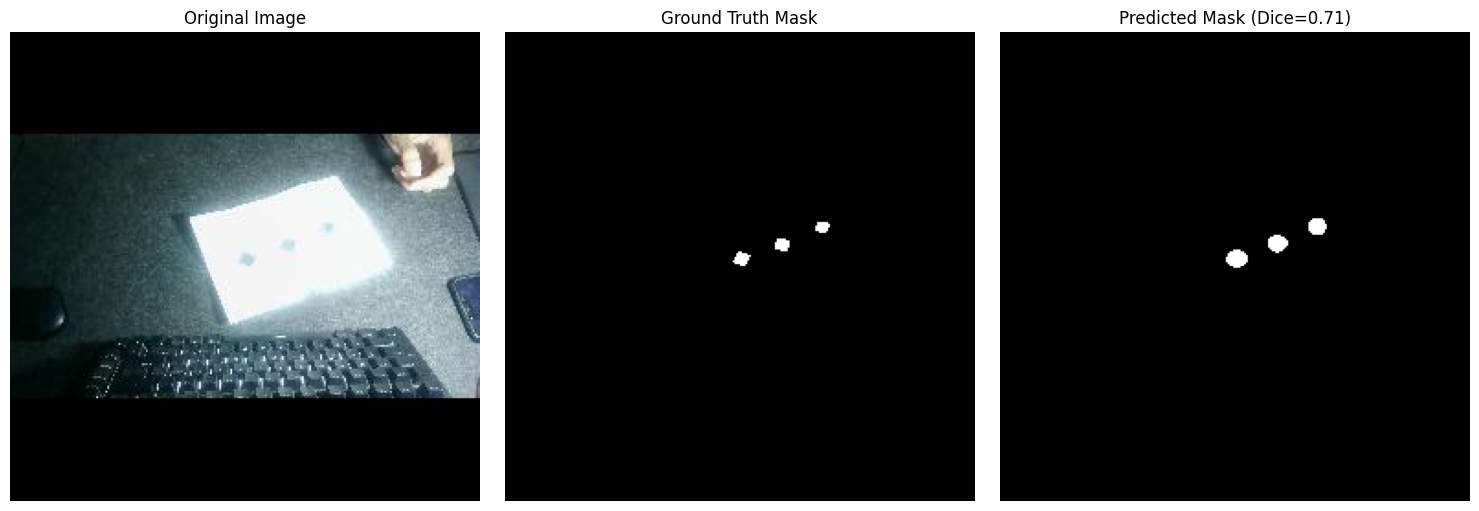

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def dice_iou_score(pred_binary, gt_binary, eps=1e-7):
    pred_binary = pred_binary.astype(bool)
    gt_binary = gt_binary.astype(bool)
    intersection = np.logical_and(pred_binary, gt_binary).sum()
    union = np.logical_or(pred_binary, gt_binary).sum()
    dice = (2 * intersection + eps) / (pred_binary.sum() + gt_binary.sum() + eps)
    iou = (intersection + eps) / (union + eps)
    return dice, iou


model = UNet().to(device)
model.load_state_dict(torch.load("unet_defect_best.pth", map_location=device))
model.eval()

idx = 0  
image, mask_gt = val_dataset[idx]
image_batch = image.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image_batch)
    pred_prob = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred_mask_binary = (pred_prob > 0.5).astype(np.uint8)

image_np = image.permute(1, 2, 0).numpy()
mask_gt_np = mask_gt.squeeze().numpy()

dice, iou = dice_iou_score(pred_mask_binary, mask_gt_np)
print(f"Pred prob -> min: {pred_prob.min():.4f}, max: {pred_prob.max():.4f}, mean: {pred_prob.mean():.4f}")
print(f"Dice score: {dice:.4f} | IoU: {iou:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask_gt_np, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

axes[2].imshow(pred_mask_binary, cmap="gray")
axes[2].set_title(f"Predicted Mask (Dice={dice:.2f})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import time
import numpy as np
import torch
import torchvision.transforms as T

# Load best model
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256          
THRESHOLD = 0.5
ALPHA = 0.5             

model = UNet().to(device)
model.load_state_dict(torch.load("unet_defect_best.pth", map_location=device))
model.eval()

# Transform 
preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])


def predict_mask(frame_bgr):
    """frame_bgr: numpy array HxWx3 (BGR from OpenCV) -> return mask biner."""
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    tensor = preprocess(frame_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()

    mask_small = (prob > THRESHOLD).astype(np.uint8) * 255
    # resize mask back to origin
    mask_full = cv2.resize(mask_small, (frame_bgr.shape[1], frame_bgr.shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask_full


def overlay_mask(frame_bgr, mask_full, color=(0, 0, 255)):
    overlay = frame_bgr.copy()
    overlay[mask_full > 0] = color
    return cv2.addWeighted(overlay, ALPHA, frame_bgr, 1 - ALPHA, 0)


# Video source
cap = cv2.VideoCapture(0)  
if not cap.isOpened():
    raise RuntimeError("can't open camera")

prev_time = time.time()

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("failed read frame from webcam.")
            break

        mask_full = predict_mask(frame)
        result = overlay_mask(frame, mask_full)

        # Calculate FPS
        curr_time = time.time()
        fps = 1.0 / max(curr_time - prev_time, 1e-6)
        prev_time = curr_time
        cv2.putText(result, f"FPS: {fps:.1f}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2.imshow("Defect Segmentation - Real-time", result)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()


In [9]:
import os

def predict_video_to_file(input_path, output_path, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise RuntimeError(f"Gagal buka video: {input_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        mask_full = predict_mask(frame)
        result = overlay_mask(frame, mask_full)
        writer.write(result)
        frame_count += 1

    cap.release()
    writer.release()
    print(f"finished. {frame_count} picture processed -> saved to {output_path}")


def predict_folder_to_file(input_dir, output_dir, img_size=IMG_SIZE):
    os.makedirs(output_dir, exist_ok=True)
    valid_ext = (".jpg", ".jpeg", ".png")
    files = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(valid_ext)])

    for f in files:
        frame = cv2.imread(os.path.join(input_dir, f))
        mask_full = predict_mask(frame)
        result = overlay_mask(frame, mask_full)
        cv2.imwrite(os.path.join(output_dir, f), result)

    print(f"finished {len(files)} picture processed -> saved to {output_dir}")




In [ ]:
import cv2
import time
import os
import numpy as np
import torch
import torchvision.transforms as T
from datetime import datetime

# Config
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256
THRESHOLD = 0.5
ALPHA = 0.5

OUTPUT_VIDEO_PATH = "webcam_output.mp4"
SNAPSHOT_DIR = "snapshots"
SNAPSHOT_COOLDOWN = 3.0   # seconds, minimum gap between auto snapshots

os.makedirs(SNAPSHOT_DIR, exist_ok=True)

# Load model
model = UNet().to(device)
model.load_state_dict(torch.load("unet_defect_best.pth", map_location=device))
model.eval()

preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])


def predict_mask(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    tensor = preprocess(frame_rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()
    mask_small = (prob > THRESHOLD).astype(np.uint8) * 255
    mask_full = cv2.resize(mask_small, (frame_bgr.shape[1], frame_bgr.shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask_full


def overlay_mask(frame_bgr, mask_full, color=(0, 0, 255)):
    overlay = frame_bgr.copy()
    overlay[mask_full > 0] = color
    return cv2.addWeighted(overlay, ALPHA, frame_bgr, 1 - ALPHA, 0)


def save_snapshot(frame):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    path = os.path.join(SNAPSHOT_DIR, f"defect_{ts}.jpg")
    cv2.imwrite(path, frame)
    return path


# Video source
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam. Check the camera index or connection.")

fps_cam = cap.get(cv2.CAP_PROP_FPS) or 20
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps_cam, (width, height))

prev_time = time.time()
last_snapshot_time = 0.0
frame_count = 0
snapshot_count = 0

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to read frame from webcam.")
            break

        mask_full = predict_mask(frame)
        result = overlay_mask(frame, mask_full)
        defect_detected = mask_full.max() > 0

        # FPS
        curr_time = time.time()
        fps = 1.0 / max(curr_time - prev_time, 1e-6)
        prev_time = curr_time

        status_text = "DEFECT DETECTED" if defect_detected else "OK"
        status_color = (0, 0, 255) if defect_detected else (0, 255, 0)
        cv2.putText(result, f"FPS: {fps:.1f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(result, status_text, (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 1, status_color, 2)

        # Record EVERY frame to the output video
        writer.write(result)
        frame_count += 1

        # Auto snapshot when a defect is detected and cooldown has passed
        if defect_detected and (curr_time - last_snapshot_time) > SNAPSHOT_COOLDOWN:
            save_snapshot(result)
            last_snapshot_time = curr_time
            snapshot_count += 1

        cv2.imshow("Defect Segmentation - Real-time (Recording)", result)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        elif key == ord("s"):
            save_snapshot(result)
            snapshot_count += 1
finally:
    cap.release()
    writer.release()
    cv2.destroyAllWindows()
    print(f"Done. {frame_count} frames recorded -> {OUTPUT_VIDEO_PATH}")
    print(f"{snapshot_count} defect snapshots saved to '{SNAPSHOT_DIR}/'")


Done. 584 frames recorded -> webcam_output.mp4
7 defect snapshots saved to 'snapshots/'
